# Timeline Breakdown — 5-Hour / 18-Sample Viscometry Window

Pie chart showing how the 5-hour automated viscometry run is distributed across human and robot activities per sample cell.

## 1. Import Required Libraries

In [47]:
import sys
from pathlib import Path

def _find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "viscometry").is_dir():
            return p
    raise RuntimeError("Could not locate repo root (expected src/viscometry)")

PROJECT_ROOT = _find_repo_root()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

AUTO_RUNS = PROJECT_ROOT / "results" / "auto_runs"
AUTO_RUNS_LEGACY = PROJECT_ROOT / "results" / "Auto-runs"
ARCHIVE = PROJECT_ROOT / "results" / "runs" / "archive"

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

print(f"matplotlib {matplotlib.__version__}")

matplotlib 3.10.0


## 2. Define Operation Parameters

In [48]:
# --- Timing per sample cell (minutes) ---
N_SAMPLES = 18
WINDOW_HOURS = 5
WINDOW_MINS = WINDOW_HOURS * 60  # 300 min

# Google brand colors
GOOGLE_BLUE   = "#4285F4"
GOOGLE_GREEN  = "#34A853"
GOOGLE_RED    = "#EA4335"
GOOGLE_YELLOW = "#FBBC05"

# Robot-assisted scenario (current process)
operations = {
    "Blending\n(human)":         {"mins_per_sample": 10, "actor": "human", "color": GOOGLE_BLUE, "human_only_mins_per_sample": 10},
    "Dispensing\n(human)":       {"mins_per_sample": 10, "actor": "human", "color": GOOGLE_GREEN, "human_only_mins_per_sample": 10},
    "Characterization\n(robot)": {"mins_per_sample": 15, "actor": "robot", "color": GOOGLE_RED, "human_only_mins_per_sample": 60},
    "Washing\n(robot)":          {"mins_per_sample":  4, "actor": "robot", "color": GOOGLE_YELLOW, "human_only_mins_per_sample": 30},
}

for name, cfg in operations.items():
    label = name.replace("\n", " ")
    print(
        f"  {label:35s} robot-assisted: {cfg['mins_per_sample']:>3} min/sample  |  "
        f"human-only: {cfg['human_only_mins_per_sample']:>3} min/sample"
    )

  Blending (human)                    robot-assisted:  10 min/sample  |  human-only:  10 min/sample
  Dispensing (human)                  robot-assisted:  10 min/sample  |  human-only:  10 min/sample
  Characterization (robot)            robot-assisted:  15 min/sample  |  human-only:  60 min/sample
  Washing (robot)                     robot-assisted:   4 min/sample  |  human-only:  30 min/sample


## 3. Calculate Timeline Metrics

In [49]:
# Total minutes per operation across all 18 samples
for name, cfg in operations.items():
    cfg["total_mins"] = cfg["mins_per_sample"] * N_SAMPLES
    cfg["total_human_only_mins"] = cfg["human_only_mins_per_sample"] * N_SAMPLES
    cfg["saved_mins"] = cfg["total_human_only_mins"] - cfg["total_mins"]

total_activity_mins = sum(cfg["total_mins"] for cfg in operations.values())
total_human_only_mins = sum(cfg["total_human_only_mins"] for cfg in operations.values())
total_saved_mins = total_human_only_mins - total_activity_mins
time_reduction_pct = total_saved_mins / total_human_only_mins * 100

print(f"{'Operation':<35} {'Robot-assisted':>15} {'Human-only':>12} {'Saved':>10}")
print("-" * 80)
for name, cfg in operations.items():
    label = name.replace("\n", " ")
    print(
        f"{label:<35} {cfg['total_mins']:>13} min {cfg['total_human_only_mins']:>10} min {cfg['saved_mins']:>8} min"
    )
print("-" * 80)
print(f"{'TOTAL (18 samples)':<35} {total_activity_mins:>13} min {total_human_only_mins:>10} min {total_saved_mins:>8} min")
print(f"Time reduction with robot support: {time_reduction_pct:.1f}%")

Operation                            Robot-assisted   Human-only      Saved
--------------------------------------------------------------------------------
Blending (human)                              180 min        180 min        0 min
Dispensing (human)                            180 min        180 min        0 min
Characterization (robot)                      270 min       1080 min      810 min
Washing (robot)                                72 min        540 min      468 min
--------------------------------------------------------------------------------
TOTAL (18 samples)                            702 min       1980 min     1278 min
Time reduction with robot support: 64.5%


## 4. Generate Pie Chart Visualization

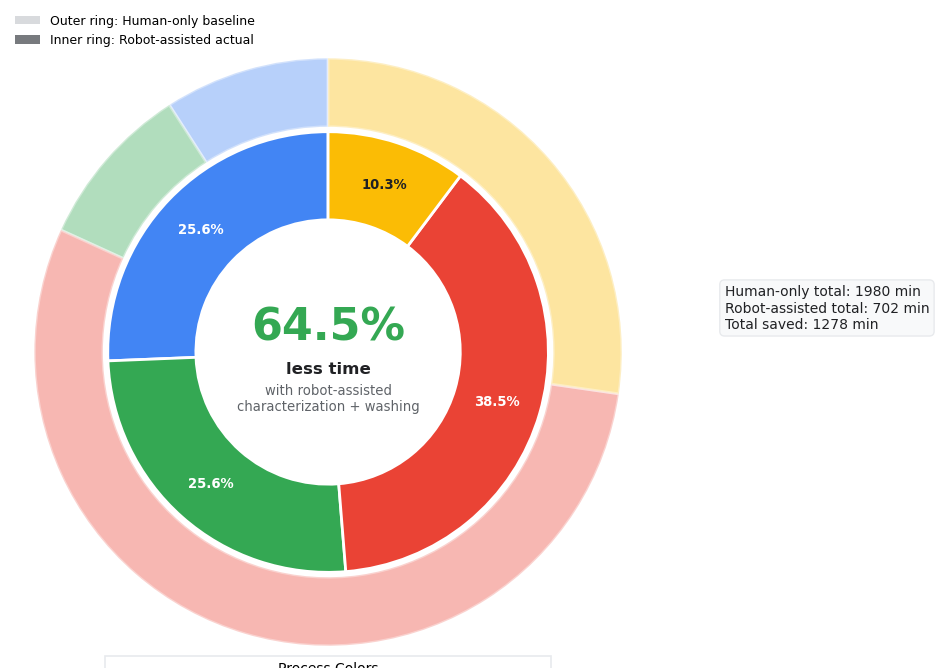

Comparison chart rendered.


In [50]:
# Compare human-only vs robot-assisted timeline using a nested donut.

labels = list(operations.keys())
colors = [cfg["color"] for cfg in operations.values()]

robot_assisted_sizes = [cfg["total_mins"] for cfg in operations.values()]
human_only_sizes = [cfg["total_human_only_mins"] for cfg in operations.values()]
savings_sizes = [cfg["saved_mins"] for cfg in operations.values()]

human_mins = sum(cfg["total_mins"] for cfg in operations.values() if cfg["actor"] == "human")
robot_mins = sum(cfg["total_mins"] for cfg in operations.values() if cfg["actor"] == "robot")

char_key = next(k for k in operations if k.startswith("Characterization"))
wash_key = next(k for k in operations if k.startswith("Washing"))

# ── Google-style figure ────────────────────────────────────────────────────────
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11})
fig, ax = plt.subplots(figsize=(9, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Outer ring: Human-only baseline (slightly transparent)
ax.pie(
    human_only_sizes,
    radius=1.20,
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.28, edgecolor="white", linewidth=2.0, alpha=0.38),
)

# Inner ring: Robot-assisted actual timeline
_, _, inner_autotexts = ax.pie(
    robot_assisted_sizes,
    radius=0.90,
    startangle=90,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%",
    pctdistance=0.80,
    wedgeprops=dict(width=0.36, edgecolor="white", linewidth=2.0),
    textprops=dict(fontsize=10),
)
for i, at in enumerate(inner_autotexts):
    at.set_fontsize(9.5)
    at.set_fontweight("bold")
    at.set_color("#202124" if colors[i] == GOOGLE_YELLOW else "white")

# Center annotation: total savings headline
ax.text(0, 0.10, f"{time_reduction_pct:.1f}%", ha="center", va="center", fontsize=32, fontweight="bold", color="#34A853")
ax.text(0, -0.07, "less time", ha="center", va="center", fontsize=12, color="#202124", fontweight="bold")
ax.text(0, -0.19, "with robot-assisted\ncharacterization + washing", ha="center", va="center", fontsize=9.5, color="#5F6368")

# Side note with absolute minutes saved
ax.text(
    1.62, 0.18,
    f"Human-only total: {total_human_only_mins} min\n"
    f"Robot-assisted total: {total_activity_mins} min\n"
    f"Total saved: {total_saved_mins} min",
    ha="left", va="center", fontsize=10, color="#202124",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#F8F9FA", edgecolor="#E8EAED"),
)

# Legend for process colors
legend_patches = [
    mpatches.Patch(facecolor=c, edgecolor="white", linewidth=1.0, label=l.replace("\n", " "))
    for l, c in zip(labels, colors)
]
leg = ax.legend(
    handles=legend_patches,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    fontsize=10.5,
    framealpha=1.0,
    edgecolor="#E8EAED",
    fancybox=False,
    title="Process Colors",
    title_fontsize=10,
)
leg.get_frame().set_linewidth(1.2)

# Ring meaning annotation
ring_legend = [
    mpatches.Patch(facecolor="#9AA0A6", alpha=0.38, edgecolor="none", label="Outer ring: Human-only baseline"),
    mpatches.Patch(facecolor="#5F6368", alpha=0.85, edgecolor="none", label="Inner ring: Robot-assisted actual"),
]
ax.legend(
    handles=ring_legend,
    loc="upper left",
    bbox_to_anchor=(-0.03, 1.07),
    fontsize=9,
    frameon=False,
)
ax.add_artist(leg)

ax.set(aspect="equal")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()
print("Comparison chart rendered.")

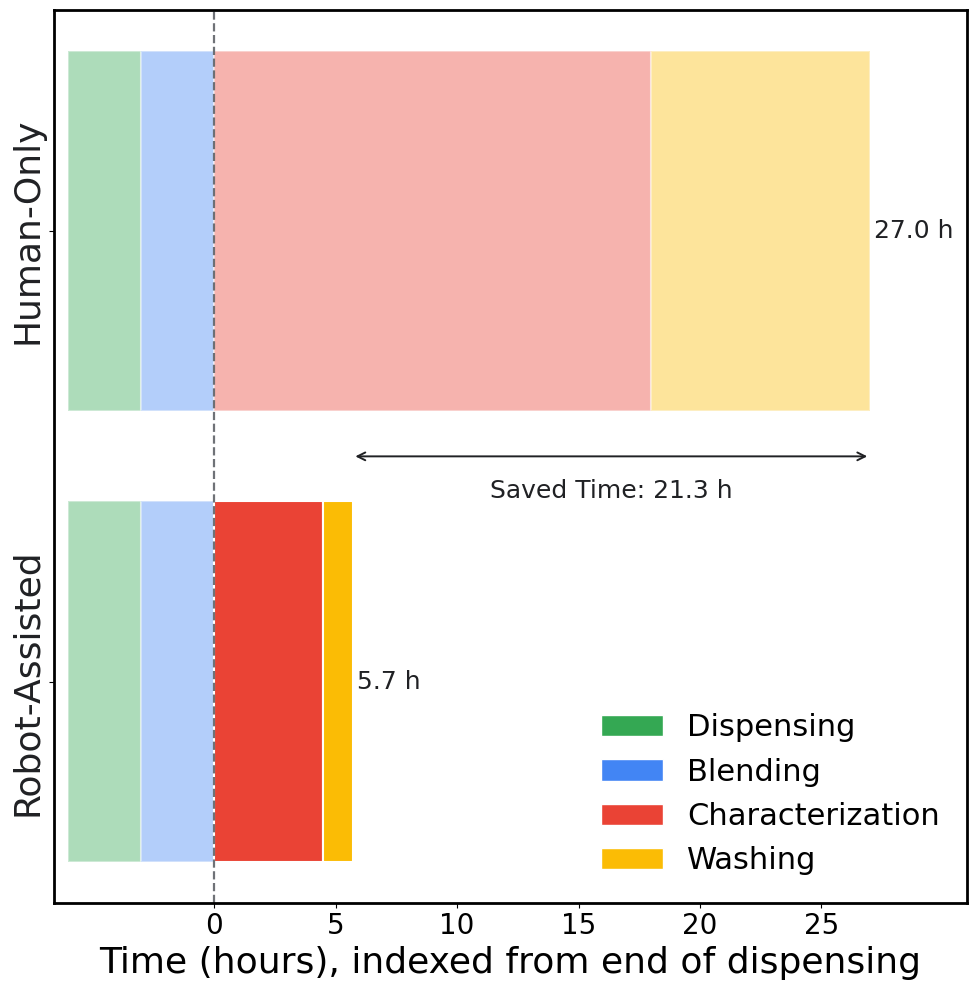

Accumulating bar chart rendered.


In [60]:
# Accumulating stacked bar comparison focused on post-dispensing stages

# Explicit order requested: Dispensing -> Blending -> Characterization -> Washing
plot_order = [1, 0, 2, 3]
ordered_items = [list(operations.items())[i] for i in plot_order]
colors_bar = [v["color"] for _, v in ordered_items]

# Convert cumulative totals to hours for x-axis display (ordered)
robot_vals_hr = [v["total_mins"] / 60.0 for _, v in ordered_items]
human_vals_hr = [v["total_human_only_mins"] / 60.0 for _, v in ordered_items]

# Cumulative positions for segment starts
a_lefts_h = []
a_lefts_r = []
acc_h = 0.0
acc_r = 0.0
for hv, rv in zip(human_vals_hr, robot_vals_hr):
    a_lefts_h.append(acc_h)
    a_lefts_r.append(acc_r)
    acc_h += hv
    acc_r += rv

# Dispensing ends after first two steps in this ordered view (Dispensing + Blending)
dispensing_end_hr = human_vals_hr[0] + human_vals_hr[1]

# Re-index x positions so 0 starts right after dispensing
lefts_h = [x - dispensing_end_hr for x in a_lefts_h]
lefts_r = [x - dispensing_end_hr for x in a_lefts_r]

total_human_only_hr = sum(human_vals_hr)
total_activity_hr = sum(robot_vals_hr)

total_human_only_rel = total_human_only_hr - dispensing_end_hr
total_activity_rel = total_activity_hr - dispensing_end_hr

# Focused saving after dispensing: characterization + washing only
focus_human_hr = sum(human_vals_hr[2:])
focus_robot_hr = sum(robot_vals_hr[2:])
focus_saved_hr = focus_human_hr - focus_robot_hr

fig_bar, ax_bar = plt.subplots(figsize=(10, 11))
fig_bar.patch.set_facecolor("white")
ax_bar.set_facecolor("white")
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 14})

# Draw cumulative (stacked) bars with requested transparency logic
for idx, (c, hv, rv, lh, lr) in enumerate(zip(colors_bar, human_vals_hr, robot_vals_hr, lefts_h, lefts_r)):
    # Human-only: all transparent
    ax_bar.barh(1, hv, left=lh, color=c, alpha=0.4, edgecolor="white", linewidth=1.5)

    # Robot-assisted: blue/green transparent, red/yellow opaque
    alpha_robot = 0.4 if idx < 2 else 1.0
    ax_bar.barh(0, rv, left=lr, color=c, alpha=alpha_robot, edgecolor="white", linewidth=1.5)

# End labels (relative to 0 = after dispensing)
ax_bar.text(total_human_only_rel + 0.18, 1, f"{total_human_only_rel:.1f} h", va="center", ha="left", fontsize=18, color="#202124")
ax_bar.text(total_activity_rel + 0.18, 0, f"{total_activity_rel:.1f} h", va="center", ha="left", fontsize=18, color="#202124")

# Mark where numbering starts
ax_bar.axvline(0, color="#5F6368", linestyle="--", linewidth=1.6, alpha=0.9)

# Black saved-time arrow and text below arrow (focus region only)
mid_y = 0.5
ax_bar.annotate(
    "",
    xy=(total_activity_rel, mid_y),
    xytext=(total_human_only_rel, mid_y),
    arrowprops=dict(arrowstyle="<->", color="#202124", lw=1.4),
)
ax_bar.text(
    (total_activity_rel + total_human_only_rel) / 2,
    mid_y - 0.05,
    f"Saved Time: {focus_saved_hr:.1f} h",
    ha="center",
    va="top",
    color="#202124",
    fontsize=18,
)

ax_bar.set_yticks([0, 1])
ax_bar.set_yticklabels(["Robot-Assisted", "Human-Only"], color="#202124", fontsize=26, rotation=90, va="center")
ax_bar.set_xlabel("Time (hours), indexed from end of dispensing", color="black", fontsize=26)

# No grid
ax_bar.grid(False)

# Border black and thicker
for spine in ["top", "right", "left", "bottom"]:
    ax_bar.spines[spine].set_visible(True)
    ax_bar.spines[spine].set_color("black")
    ax_bar.spines[spine].set_linewidth(2)

# Show blending/dispensing (negative side) while numbering origin starts at dispensing
left_limit = -(dispensing_end_hr + 0.6)
right_limit = total_human_only_rel + 1.4
ax_bar.set_xlim(left_limit, 31)

# Show x-axis numbering only from 0 onward
xticks = np.arange(0, right_limit + 0.001, 5.0)
ax_bar.set_xticks(xticks)
ax_bar.set_xticklabels([f"{x:g}" for x in xticks], color="black", fontsize=20)

# Corrected legend labels/order requested (4 labels)
legend_labels = ["Dispensing", "Blending", "Characterization", "Washing"]
legend_colors = [GOOGLE_GREEN, GOOGLE_BLUE, GOOGLE_RED, GOOGLE_YELLOW]
legend_handles = [
    mpatches.Patch(facecolor=c, edgecolor="white", linewidth=1.0, label=l)
    for l, c in zip(legend_labels, legend_colors)
]
ax_bar.legend(
    handles=legend_handles,
    loc="lower right",
    ncol=1,
    framealpha=1.0,
    frameon=False,
    edgecolor="#E8EAED",
    fancybox=False,
    fontsize=22,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()
print("Accumulating bar chart rendered.")

## 5. Export SVG Plot

In [52]:
output_dir = Path(r"c:\Users\mrast\OneDrive\Documents\GitHub\Automated_Viscometry\Images")
svg_pie_path = output_dir / "timeline_breakdown_pie.svg"
svg_bar_path = output_dir / "timeline_breakdown_bar.svg"

char_key = next(k for k in operations if k.startswith("Characterization"))
wash_key = next(k for k in operations if k.startswith("Washing"))

# =========================
# Export 1: Donut chart SVG
# =========================
fig2, ax2 = plt.subplots(figsize=(9, 8))
fig2.patch.set_facecolor("white")
ax2.set_facecolor("white")

# Outer ring: Human-only baseline
ax2.pie(
    human_only_sizes,
    radius=1.20,
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.28, edgecolor="white", linewidth=2.0, alpha=0.38),
)

# Inner ring: Robot-assisted actual timeline
_, _, inner_autotexts2 = ax2.pie(
    robot_assisted_sizes,
    radius=0.90,
    startangle=90,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%",
    pctdistance=0.80,
    wedgeprops=dict(width=0.36, edgecolor="white", linewidth=2.0),
    textprops=dict(fontsize=10),
)
for i, at in enumerate(inner_autotexts2):
    at.set_fontsize(9.5)
    at.set_fontweight("bold")
    at.set_color("#202124" if colors[i] == GOOGLE_YELLOW else "white")

ax2.text(0, 0.10, f"{time_reduction_pct:.1f}%", ha="center", va="center", fontsize=32, fontweight="bold", color="#34A853")
ax2.text(0, -0.07, "less time", ha="center", va="center", fontsize=12, color="#202124", fontweight="bold")
ax2.text(0, -0.19, "with robot-assisted\ncharacterization + washing", ha="center", va="center", fontsize=9.5, color="#5F6368")

ax2.text(
    1.62, 0.18,
    f"Human-only total: {total_human_only_mins} min\n"
    f"Robot-assisted total: {total_activity_mins} min\n"
    f"Total saved: {total_saved_mins} min",
    ha="left", va="center", fontsize=10, color="#202124",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#F8F9FA", edgecolor="#E8EAED"),
)

legend_patches = [
    mpatches.Patch(facecolor=c, edgecolor="white", linewidth=1.0, label=l.replace("\n", " "))
    for l, c in zip(labels, colors)
]
leg2 = ax2.legend(
    handles=legend_patches,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    fontsize=10.5,
    framealpha=1.0,
    edgecolor="#E8EAED",
    fancybox=False,
    title="Process Colors",
    title_fontsize=10,
)
leg2.get_frame().set_linewidth(1.2)

ring_legend2 = [
    mpatches.Patch(facecolor="#9AA0A6", alpha=0.38, edgecolor="none", label="Outer ring: Human-only baseline"),
    mpatches.Patch(facecolor="#5F6368", alpha=0.85, edgecolor="none", label="Inner ring: Robot-assisted actual"),
]
ax2.legend(
    handles=ring_legend2,
    loc="upper left",
    bbox_to_anchor=(-0.03, 1.07),
    fontsize=9,
    frameon=False,
)
ax2.add_artist(leg2)

ax2.set_title(
    f"Timeline Impact of Robot Assistance - {N_SAMPLES} Samples",
    fontsize=15,
    fontweight="bold",
    color="#202124",
    pad=26,
)
fig2.text(
    0.5,
    0.02,
    (
        f"Characterization: {operations[char_key]['human_only_mins_per_sample']}->{operations[char_key]['mins_per_sample']} min/sample, "
        f"Washing: {operations[wash_key]['human_only_mins_per_sample']}->{operations[wash_key]['mins_per_sample']} min/sample"
    ),
    ha="center",
    fontsize=9,
    color="#5F6368",
)

ax2.set(aspect="equal")
plt.tight_layout(rect=[0, 0.04, 1, 1])
fig2.savefig(svg_pie_path, format="svg", bbox_inches="tight", facecolor="white")
plt.close(fig2)

# ========================
# Export 2: Bar chart SVG
# ========================
plot_order = [1, 0, 2, 3]
ordered_items = [list(operations.items())[i] for i in plot_order]
colors_bar = [v["color"] for _, v in ordered_items]

robot_vals_hr = [v["total_mins"] / 60.0 for _, v in ordered_items]
human_vals_hr = [v["total_human_only_mins"] / 60.0 for _, v in ordered_items]

a_lefts_h = []
a_lefts_r = []
acc_h = 0.0
acc_r = 0.0
for hv, rv in zip(human_vals_hr, robot_vals_hr):
    a_lefts_h.append(acc_h)
    a_lefts_r.append(acc_r)
    acc_h += hv
    acc_r += rv

dispensing_end_hr = human_vals_hr[0] + human_vals_hr[1]
lefts_h = [x - dispensing_end_hr for x in a_lefts_h]
lefts_r = [x - dispensing_end_hr for x in a_lefts_r]

total_human_only_hr = sum(human_vals_hr)
total_activity_hr = sum(robot_vals_hr)
total_human_only_rel = total_human_only_hr - dispensing_end_hr
total_activity_rel = total_activity_hr - dispensing_end_hr
focus_human_hr = sum(human_vals_hr[2:])
focus_robot_hr = sum(robot_vals_hr[2:])
focus_saved_hr = focus_human_hr - focus_robot_hr

fig_bar, ax_bar = plt.subplots(figsize=(11.5, 5.0))
fig_bar.patch.set_facecolor("white")
ax_bar.set_facecolor("white")
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11})

for idx, (c, hv, rv, lh, lr) in enumerate(zip(colors_bar, human_vals_hr, robot_vals_hr, lefts_h, lefts_r)):
    ax_bar.barh(1, hv, left=lh, color=c, alpha=0.22, edgecolor="white", linewidth=1.5)
    alpha_robot = 0.22 if idx < 2 else 0.98
    ax_bar.barh(0, rv, left=lr, color=c, alpha=alpha_robot, edgecolor="white", linewidth=1.5)

ax_bar.text(total_human_only_rel + 0.18, 1, f"{total_human_only_rel:.1f} h", va="center", ha="left", fontsize=11, color="#202124")
ax_bar.text(total_activity_rel + 0.18, 0, f"{total_activity_rel:.1f} h", va="center", ha="left", fontsize=11, color="#202124")

ax_bar.axvline(0, color="#5F6368", linestyle="--", linewidth=1.6, alpha=0.9)
mid_y = 0.5
ax_bar.annotate(
    "",
    xy=(total_activity_rel, mid_y),
    xytext=(total_human_only_rel, mid_y),
    arrowprops=dict(arrowstyle="<->", color="#202124", lw=1.4),
)
ax_bar.text(
    (total_activity_rel + total_human_only_rel) / 2,
    mid_y - 0.13,
    f"Saved Time: {focus_saved_hr:.1f} h",
    ha="center",
    va="top",
    color="#202124",
    fontsize=10.5,
)

ax_bar.set_yticks([0, 1])
ax_bar.set_yticklabels(["Robot-Assisted", "Human-Only"], color="#202124", fontsize=14)
ax_bar.set_xlabel("Time (hours), indexed from end of dispensing", color="black", fontsize=14)

ax_bar.grid(False)
for spine in ["top", "right", "left", "bottom"]:
    ax_bar.spines[spine].set_visible(True)
    ax_bar.spines[spine].set_color("black")
    ax_bar.spines[spine].set_linewidth(1)

left_limit = -(dispensing_end_hr + 0.6)
right_limit = total_human_only_rel + 1.4
ax_bar.set_xlim(left_limit, 29)
xticks = np.arange(0, right_limit + 0.001, 5.0)
ax_bar.set_xticks(xticks)
ax_bar.set_xticklabels([f"{x:g}" for x in xticks], color="black")

legend_labels = ["Dispensing", "Blending", "Characterization", "Washing"]
legend_colors = [GOOGLE_GREEN, GOOGLE_BLUE, GOOGLE_RED, GOOGLE_YELLOW]
legend_handles = [
    mpatches.Patch(facecolor=c, edgecolor="white", linewidth=1.0, label=l)
    for l, c in zip(legend_labels, legend_colors)
]
ax_bar.legend(
    handles=legend_handles,
    loc="lower right",
    ncol=2,
    framealpha=1.0,
    frameon=False,
    edgecolor="#E8EAED",
    fancybox=False,
    fontsize=12,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
fig_bar.savefig(svg_bar_path, format="svg", bbox_inches="tight", facecolor="white")
plt.close(fig_bar)

print(f"Pie SVG saved -> {svg_pie_path}")
print(f"Bar SVG saved -> {svg_bar_path}")

Pie SVG saved -> c:\Users\mrast\OneDrive\Documents\GitHub\Automated_Viscometry\Images\timeline_breakdown_pie.svg
Bar SVG saved -> c:\Users\mrast\OneDrive\Documents\GitHub\Automated_Viscometry\Images\timeline_breakdown_bar.svg
